### Libraries & Data importing

In [89]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
import sklearn

In [90]:
df = pd.read_csv(r'data\amazon_alexa.tsv',sep="\t")
df.head()

,rating,date,variation,verified_reviews,feedback
0,5,31-Jul-18,Charcoal Fabric,Love my Echo!,1
1,5,31-Jul-18,Charcoal Fabric,Loved it!,1
2,4,31-Jul-18,Walnut Finish,"Sometimes while playing a game, you can answer...",1
3,5,31-Jul-18,Charcoal Fabric,I have had a lot of fun with this thing. My 4 ...,1
4,5,31-Jul-18,Charcoal Fabric,Music,1


### Data Exploration & Cleaning

In [91]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3150 entries, 0 to 3149
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   rating            3150 non-null   int64 
 1   date              3150 non-null   object
 2   variation         3150 non-null   object
 3   verified_reviews  3149 non-null   object
 4   feedback          3150 non-null   int64 
dtypes: int64(2), object(3)
memory usage: 123.2+ KB


In [92]:
df.shape

(3150, 5)

In [93]:
df.isnull().sum()

rating              0
date                0
variation           0
verified_reviews    1
feedback            0
dtype: int64

In [94]:
df.dropna(inplace=True)

In [95]:
df.isnull().sum()

rating              0
date                0
variation           0
verified_reviews    0
feedback            0
dtype: int64

In [96]:
df.dtypes

rating               int64
date                object
variation           object
verified_reviews    object
feedback             int64
dtype: object

In [97]:
df['rating'].value_counts()

rating
5    2286
4     455
1     161
3     152
2      95
Name: count, dtype: int64

--> we have to divide the rating into 2 classes (positive and negative)


In [98]:
# percentage distribution of rating
print(f"percentage distribution of ratings: \n{round(df['rating'].value_counts()/df.shape[0]*100,2)}")

percentage distribution of ratings: 
rating
5    72.59
4    14.45
1     5.11
3     4.83
2     3.02
Name: count, dtype: float64


--> Mostly ratings are positive (5 & 4)

In [99]:
df.columns

Index(['rating', 'date', 'variation', 'verified_reviews', 'feedback'], dtype='object')

In [100]:
# we don't need 'Date' column 
df.drop(columns='date',inplace=True)

In [101]:
# total viriations(models) of alexa
df['variation'].unique().shape[0]

16

In [102]:
df['variation'].value_counts()

variation
Black  Dot                      516
Charcoal Fabric                 430
Configuration: Fire TV Stick    350
Black  Plus                     270
Black  Show                     265
Black                           261
Black  Spot                     241
White  Dot                      184
Heather Gray Fabric             157
White  Spot                     109
Sandstone Fabric                 90
White                            90
White  Show                      85
White  Plus                      78
Oak Finish                       14
Walnut Finish                     9
Name: count, dtype: int64

In [103]:
df.head()

,rating,variation,verified_reviews,feedback
0,5,Charcoal Fabric,Love my Echo!,1
1,5,Charcoal Fabric,Loved it!,1
2,4,Walnut Finish,"Sometimes while playing a game, you can answer...",1
3,5,Charcoal Fabric,I have had a lot of fun with this thing. My 4 ...,1
4,5,Charcoal Fabric,Music,1


In [104]:
df['feedback'].value_counts()

feedback
1    2893
0     256
Name: count, dtype: int64

In [105]:
print('---positive feedback with rating classes---')
print(df[df['feedback'] == 1]['rating'].value_counts())
print('\n---negative feedback with rating classes---')
print(df[df['feedback'] == 0]['rating'].value_counts())

---positive feedback with rating classes---
rating
5    2286
4     455
3     152
Name: count, dtype: int64

---negative feedback with rating classes---
rating
1    161
2     95
Name: count, dtype: int64


In [106]:
# percentage of positive and negative feedback
df['feedback'].value_counts()/df.shape[0]*100

feedback
1    91.870435
0     8.129565
Name: count, dtype: float64

In [107]:
df.head()

,rating,variation,verified_reviews,feedback
0,5,Charcoal Fabric,Love my Echo!,1
1,5,Charcoal Fabric,Loved it!,1
2,4,Walnut Finish,"Sometimes while playing a game, you can answer...",1
3,5,Charcoal Fabric,I have had a lot of fun with this thing. My 4 ...,1
4,5,Charcoal Fabric,Music,1


### Preprocessing

In [108]:
df = df[['verified_reviews', 'feedback']]

In [109]:
df

,verified_reviews,feedback
0,Love my Echo!,1
1,Loved it!,1
2,"Sometimes while playing a game, you can answer...",1
3,I have had a lot of fun with this thing. My 4 ...,1
4,Music,1
...,...,...
3145,"Perfect for kids, adults and everyone in betwe...",1
3146,"Listening to music, searching locations, check...",1
3147,"I do love these things, i have them running my...",1
3148,Only complaint I have is that the sound qualit...,1


In [110]:
# Combine all reviews for each feedback category and splitting them into individual words
neg_reviews = " ".join([review for review in df[df['feedback'] == 0]['verified_reviews']])
neg_reviews = neg_reviews.lower().split()

pos_reviews = " ".join([review for review in df[df['feedback'] == 1]['verified_reviews']])
pos_reviews = pos_reviews.lower().split()


In [111]:
#Finding words from reviews which are present in that feedback category only
unique_negative = [x for x in neg_reviews if x not in pos_reviews]
unique_negative = " ".join(unique_negative)

unique_positive = [x for x in pos_reviews if x not in neg_reviews]
unique_positive = " ".join(unique_positive)


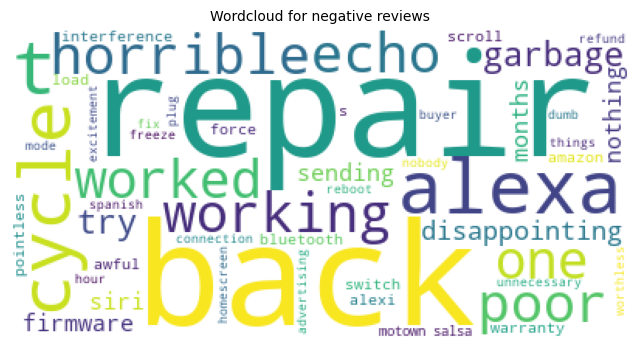

In [112]:
from wordcloud import WordCloud

wc = WordCloud(background_color='white', max_words=50)

# Generate and plot wordcloud
plt.figure(figsize=(8,8))
plt.imshow(wc.generate(unique_negative))
plt.title('Wordcloud for negative reviews', fontsize=10)
plt.axis('off')
plt.show()

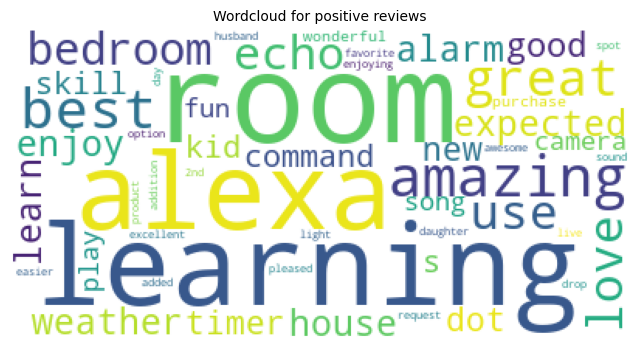

In [113]:
wc = WordCloud(background_color='white', max_words=50)

# Generate and plot wordcloud
plt.figure(figsize=(8,8))
plt.imshow(wc.generate(unique_positive))
plt.title('Wordcloud for positive reviews', fontsize=10)
plt.axis('off')
plt.show()

In [114]:
import re
from nltk.stem import WordNetLemmatizer
nltk.download('stopwords')
from nltk.corpus import stopwords

lemmatizer = WordNetLemmatizer()
stopwords_eng = set(stopwords.words('english'))

def clean_text(text):
    review = re.sub('[^a-zA-Z]', ' ', text)
    review = review.lower().split()
    review = [lemmatizer.lemmatize(word) for word in review if word not in stopwords_eng]
    return ' '.join(review)


[nltk_data] Downloading package stopwords to C:\Users\Pardeep
[nltk_data]     Sukheja/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [115]:
df['cleaned'] = df['verified_reviews'].apply(clean_text)

In [116]:
df.head()

,verified_reviews,feedback,cleaned
0,Love my Echo!,1,love echo
1,Loved it!,1,loved
2,"Sometimes while playing a game, you can answer...",1,sometimes playing game answer question correct...
3,I have had a lot of fun with this thing. My 4 ...,1,lot fun thing yr old learns dinosaur control l...
4,Music,1,music


### Train Test Split

In [117]:
X = df['cleaned']
y = df['feedback']

In [118]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 40)

In [119]:
X_train.shape,y_train.shape,X_test.shape,y_test.shape

((2519,), (2519,), (630,), (630,))

In [120]:
# TExt to vectors


from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1,2))
X_train_vec = tfidf.fit_transform(X_train)
X_test_vec = tfidf.transform(X_test)

### model training

In [143]:
# tuning models
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import ComplementNB,MultinomialNB
from sklearn.metrics import f1_score, classification_report

models = {
    "Logistic Regression": LogisticRegression(max_iter=500, class_weight='balanced'),
    "Naive Bayes": ComplementNB(),
    "Linear SVM": LinearSVC(class_weight='balanced')
}

results = {}

for name, model in models.items():
    model.fit(X_train_vec, y_train)
    pred = model.predict(X_test_vec)
    f1 = f1_score(y_test, pred, average='binary')  # Positive class F1
    results[name] = f1
    print(f"\n------ {name} ------")
    print("F1 Score:", f1)
    print(classification_report(y_test, pred))



------ Logistic Regression ------
F1 Score: 0.9475555555555556
              precision    recall  f1-score   support

           0       0.51      0.63      0.56        60
           1       0.96      0.94      0.95       570

    accuracy                           0.91       630
   macro avg       0.73      0.78      0.76       630
weighted avg       0.92      0.91      0.91       630


------ Naive Bayes ------
F1 Score: 0.951240376390077
              precision    recall  f1-score   support

           0       0.55      0.28      0.37        60
           1       0.93      0.98      0.95       570

    accuracy                           0.91       630
   macro avg       0.74      0.63      0.66       630
weighted avg       0.89      0.91      0.90       630


------ Linear SVM ------
F1 Score: 0.9479258605472197
              precision    recall  f1-score   support

           0       0.51      0.57      0.54        60
           1       0.95      0.94      0.95       570

    accu

We evaluated multiple algorithms including Complement Naive Bayes, Logistic Regression, and Linear SVM. Due to class imbalance (91% positive, 9% negative), Complement Naive Bayes struggled to detect negative sentiment (F1=0.37 for negative class). Linear SVM performed better (F1=0.54), while Logistic Regression achieved the highest balanced performance (F1=0.56) and was therefore selected as the final model.

In [145]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=400, class_weight='balanced') # class weights for minority class.
model.fit(X_train_vec, y_train)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'lbfgs'
,max_iter,400
,multi_class,'deprecated'


In [146]:
y_pred = model.predict(X_test_vec)

In [147]:
# We do NOT use accuracy (it will be misleading due to imbalance).
# We focus on F1-score, particularly negative class F1.

from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(y_test,y_pred))



              precision    recall  f1-score   support

           0       0.51      0.63      0.56        60
           1       0.96      0.94      0.95       570

    accuracy                           0.91       630
   macro avg       0.73      0.78      0.76       630
weighted avg       0.92      0.91      0.91       630



#### Hyperparameter Tuning


In [148]:
params = {
    'penalty' : ['l1', 'l2', 'elasticnet', None],
    'C':[0.1,1,3,5,10],
    'solver':['lbfgs','liblinear','sag'],
    'class_weight':['balanced']
}

In [149]:
from sklearn.model_selection import GridSearchCV

grid = GridSearchCV(model, param_grid=params, cv=5, scoring='f1')
grid.fit(X_train_vec, y_train)

c:\applications\anaconda3\envs\prj_3.13\Lib\site-packages\sklearn\linear_model\_logistic.py:1232: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(
c:\applications\anaconda3\envs\prj_3.13\Lib\site-packages\sklearn\linear_model\_logistic.py:1232: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(
c:\applications\anaconda3\envs\prj_3.13\Lib\site-packages\sklearn\linear_model\_logistic.py:1232: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(
c:\applications\anaconda3\envs\prj_3.13\Lib\site-packages\sklearn\linear_model\_logistic.py:1232: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(
c:\applications\anaconda3\envs\prj_3.13\Lib\site-packages\sklearn\linear_model\_logistic.py:1232: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(
c:\applications\anaconda3\envs\prj_3.13\Lib\s

,estimator,LogisticRegre... max_iter=400)
,param_grid,"{'C': [0.1, 1, ...], 'class_weight': ['balanced'], 'penalty': ['l1', 'l2', ...], 'solver': ['lbfgs', 'liblinear', ...]}"
,scoring,'f1'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,penalty,'l2'


In [152]:
pred = grid.predict(X_test_vec)
print(classification_report(y_test, pred, digits=4))
print(confusion_matrix(y_test, pred))


              precision    recall  f1-score   support

           0     0.5484    0.5667    0.5574        60
           1     0.9542    0.9509    0.9525       570

    accuracy                         0.9143       630
   macro avg     0.7513    0.7588    0.7550       630
weighted avg     0.9156    0.9143    0.9149       630

[[ 34  26]
 [ 28 542]]


In [153]:
grid.best_params_

{'C': 3, 'class_weight': 'balanced', 'penalty': 'l2', 'solver': 'lbfgs'}

In [155]:
import pickle

best_model = LogisticRegression(C=3,class_weight='balanced',penalty='l2',solver='lbfgs')
best_model.fit(X_train_vec, y_train)

pickle.dump(best_model, open("sentiment_model.pkl", "wb"))
pickle.dump(tfidf, open("tfidf_vectorizer.pkl", "wb"))


In [156]:
def predict_sentiment(text):
    cleaned = clean_text(text)
    vector = tfidf.transform([cleaned])
    pred = best_model.predict(vector)[0]
    return "Positive" if pred == 1 else "Negative"


In [157]:
print(predict_sentiment("I love this product, works perfectly!"))
print(predict_sentiment("Terrible, waste of money."))
print(predict_sentiment("Quality is average."))
print(predict_sentiment("The device works fine, but sometimes it's slow."))
print(predict_sentiment("I am extremely happy with the Alexa service."))
print(predict_sentiment("Not satisfied, it stopped responding frequently."))
print(predict_sentiment("Alexa is amazing, very useful for my smart home."))
print(predict_sentiment("I would recommend Alexa to all my friends."))
print(predict_sentiment("Alexa is amazing, very useful for my smart home.."))
print(predict_sentiment('The sound quality is okay, but not great.'))
print(predict_sentiment("It doesn't do half of what it promises, disappointed."))

Positive
Negative
Positive
Negative
Positive
Negative
Positive
Positive
Positive
Positive
Negative
